In [34]:
# visualize the MAMujoco Datasets

import numpy as np
import matplotlib.pyplot as plt

# import gym envs
from gym.spaces import Box, Discrete
from utils.make_env import make_env
from utils.env_wrappers import DummyVecEnv

# env check
try:
    from multiagent_mujoco.mujoco_multi import MujocoMulti
except:
    print ('MujocoMulti not installed')

from bandit import ContinuousBanditEnv

from utils.buffer import ReplayBuffer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# make parallel MA-Env
def make_parallel_env(env_id, seed, discrete_action):
    def get_env_fn(rank):
        env = make_env(env_id, discrete_action=discrete_action)
        env.seed(seed + rank * 1000)
        np.random.seed(seed + rank * 1000)
        return env
    return DummyVecEnv([get_env_fn(0)])


In [36]:
def vis_data(env_id, data_type, dataset_id, seed):

    discrete_action = False
    device = f"cuda:{1}"
    rew_scale = 1.0
    dataset_dir = '/home/qiaodan/Code/diffmarl/datasets' + '/' + env_id + '/' + data_type + '/' + 'seed_{}_data'.format(dataset_id)

    if env_id == 'HalfCheetah-v2':
        nagents = 2
        buffer_length = int(1e6)  # dataset transitions numbers
        episode_length = int(1000)
    elif env_id in ['simple_spread', 'simple_tag', 'simple_world']:
        nagents = 3
        buffer_length = int(1e6)
        episode_length = int(25)

    batch_size = 1000
    use_gpu = True

    ### make env
    if env_id in ['simple_spread', 'simple_tag', 'simple_world']:
        env = make_parallel_env(env_id, seed, discrete_action)
        env_args, env_info = None, None
    elif env_id == "bandit":
        env = ContinuousBanditEnv()
        env_args, env_info = None, None
    else:
        env_args = {"scenario": env_id, "episode_limit": 1000, "agent_conf": '2x3', "agent_obsk": 0,}
        env = MujocoMulti(env_args=env_args)
        env.seed(seed)
        env_info = env.get_env_info()

    # load full offline datasets to buffer
    if env_id in ['simple_spread', 'simple_tag', 'simple_world', 'bandit']:
        replay_buffer = ReplayBuffer(
            buffer_length, nagents,
            [obsp.shape[0] for obsp in env.observation_space],
            [acsp.shape[0] if isinstance(acsp, Box) else acsp.n for acsp in env.action_space], device = device
        )
    else:
        replay_buffer = ReplayBuffer(
            buffer_length, nagents,
            [env_info['obs_shape'] for _ in env.observation_space],
            [acsp.shape[0] for acsp in env.action_space],
            is_mamujoco=True,
            state_dims=[env_info['state_shape'] for _ in env.observation_space], device = device
        )
    replay_buffer.load_batch_data(dataset_dir, rew_scale = rew_scale)

    if np.isinf(replay_buffer.ave_reward):   # 如果变量是 inf, 代表这条轨迹没有 done=True，要进行 scale
        replay_buffer.ave_reward = replay_buffer.sum_reward / (replay_buffer.filled_i/episode_length)
    print('Average_reward:', replay_buffer.ave_reward)

    sample = replay_buffer.sample(batch_size, to_gpu=use_gpu)


    # replay_buffer.obs_buffs[0].shape, replay_buffer.obs_buffs[0]
    states = replay_buffer.state_buffs[0]
    actions = np.concatenate((replay_buffer.ac_buffs[0], replay_buffer.ac_buffs[1]), axis=1)


    # 将状态降维到2维
    state_pca = PCA(n_components=2)
    states_2d = state_pca.fit_transform(states)

    # 将动作降维到2维
    action_pca = PCA(n_components=2)
    actions_2d = action_pca.fit_transform(actions)

    # 归一化到0-1范围
    scaler = MinMaxScaler()
    actions_2d_normalized = scaler.fit_transform(actions_2d)

    # 分别生成动作的颜色
    action_colors_x = plt.cm.Blues(actions_2d_normalized[:, 0])
    action_colors_y = plt.cm.PuRd(actions_2d_normalized[:, 1])

    # 混合动作颜色
    mixed_colors = (action_colors_x[:, :3] + action_colors_y[:, :3]) / 2


    # 绘制散点图
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(states_2d[:, 0], states_2d[:, 1], c=mixed_colors, s=10)
    ax.set_xlim([-50,50])
    ax.set_ylim([-50,50])
    ax.set_xlabel('State Dimension 1 (PCA)')
    ax.set_ylabel('State Dimension 2 (PCA)')
    ax.set_title('Visualization of Offline Multi-Agent RL Dataset-{}-{}'.format(data_type, dataset_id))

    # 在主图中插入颜色渐变 bar
    axins = inset_axes(ax, width="5%", height="50%", loc='upper right', borderpad=1)

    gradient = np.linspace(0, 1, 256)
    gradient = np.vstack((gradient, gradient))

    # 创建自定义 colormap
    cmap = np.empty((256, 256, 3))
    for i in range(256):
        for j in range(256):
            blue = np.array(plt.cm.Blues(gradient[0, i])[:3])
            red = np.array(plt.cm.PuRd(gradient[0, j])[:3])
            cmap[i, j, :] = (blue + red) / 2

    axins.imshow(cmap, aspect='auto', extent=[0, 1, 0, 1])
    axins.set_title('Action Color Legend', fontsize=8)
    axins.set_xlabel('Act. Dim 1', fontsize=8)
    axins.set_ylabel('Act. Dim 2', fontsize=8)
    axins.xaxis.set_label_position('top')
    axins.xaxis.set_ticks_position('top')
    axins.yaxis.set_ticks_position('left')
    axins.tick_params(axis='both', which='major', labelsize=6)



    # # 绘制散点图
    # plt.scatter(states_2d[:, 0], states_2d[:, 1], c=mixed_colors, s=10)
    # plt.xlabel('State Dimension 1 (PCA)')
    # plt.ylabel('State Dimension 2 (PCA)')
    # plt.title('Visualization of Offline Multi-Agent RL Dataset-{}-{}'.format(data_type, dataset_id))
    # # plt.savefig(os.path.join('/home/qiaodan/Code/diffmarl/datasets', 'HC_data_dis.png'), dpi=300, format='png', bbox_inches='tight', pad_inches=0.1)


    plt.show()

/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/expert/seed_0_data...
Average_reward: 3338.688488713757


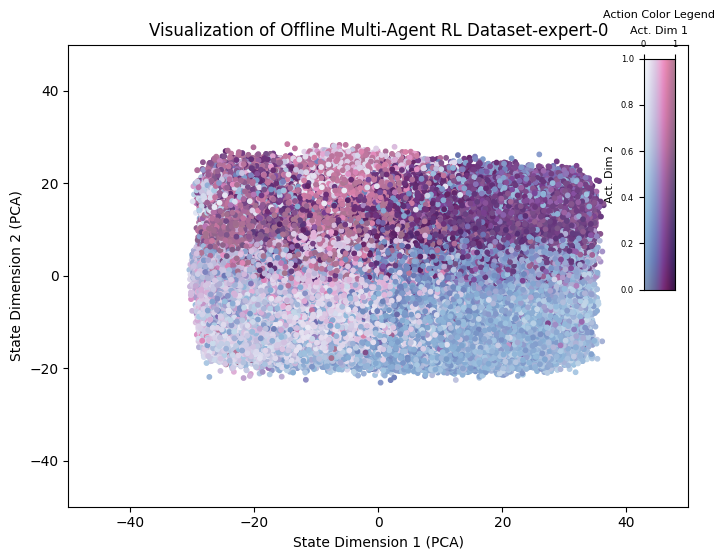

In [37]:
# dataset params
env_id = 'HalfCheetah-v2'  # MPE
data_type = 'expert'  # random medium
dataset_id = 0  # 1 2 3 4
seed = 42

vis_data(env_id, data_type, dataset_id, seed)



/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/expert/seed_1_data...
Average_reward: 3599.979033156354


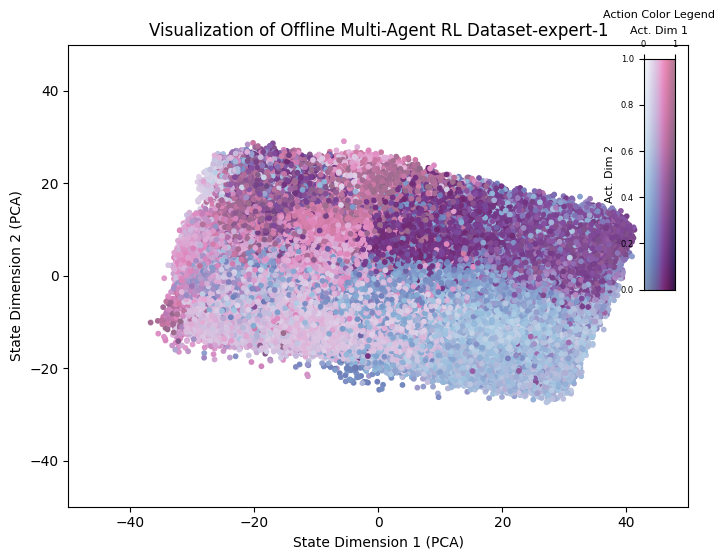

In [38]:
# dataset params
env_id = 'HalfCheetah-v2'  # MPE
data_type = 'expert'  # random medium
dataset_id = 1  # 1 2 3 4
seed = 42

vis_data(env_id, data_type, dataset_id, seed)


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/expert/seed_2_data...
Average_reward: 3727.38474097388


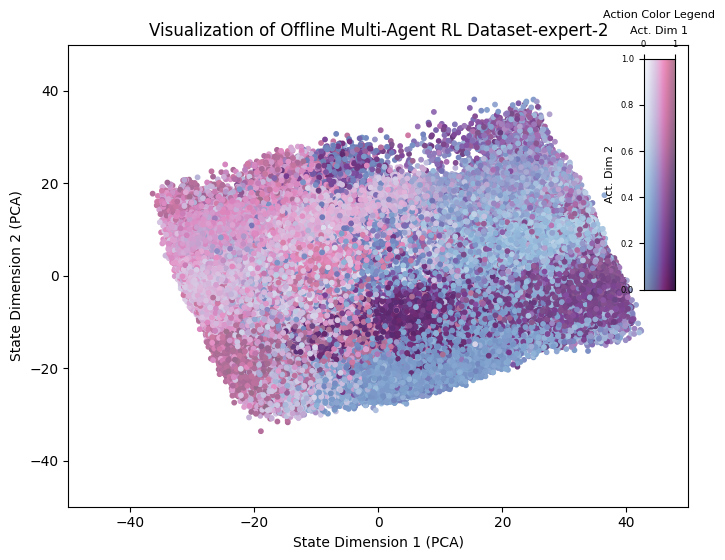

In [39]:
# dataset params
env_id = 'HalfCheetah-v2'  # MPE
data_type = 'expert'  # random medium
dataset_id = 2  # 1 2 3 4
seed = 42

vis_data(env_id, data_type, dataset_id, seed)


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/expert/seed_3_data...
Average_reward: 3612.2442804429784


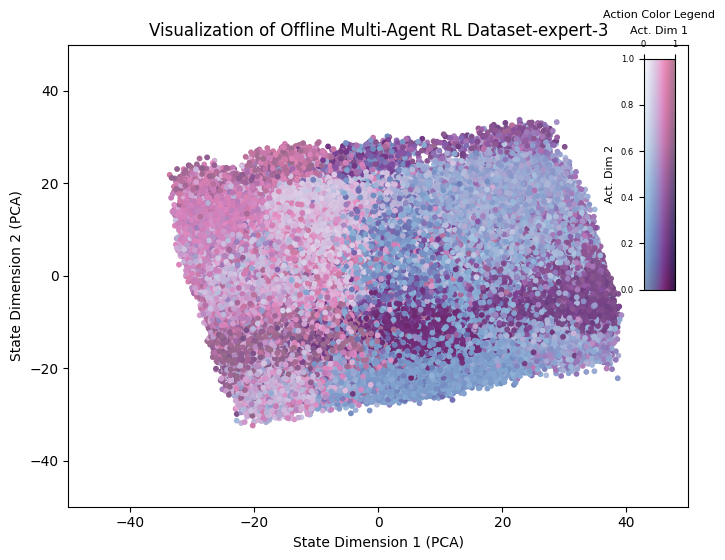

In [40]:
# dataset params
env_id = 'HalfCheetah-v2'  # MPE
data_type = 'expert'  # random medium
dataset_id = 3  # 1 2 3 4
seed = 42

vis_data(env_id, data_type, dataset_id, seed)


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/medium/seed_0_data...
Average_reward: 1568.8693258918715


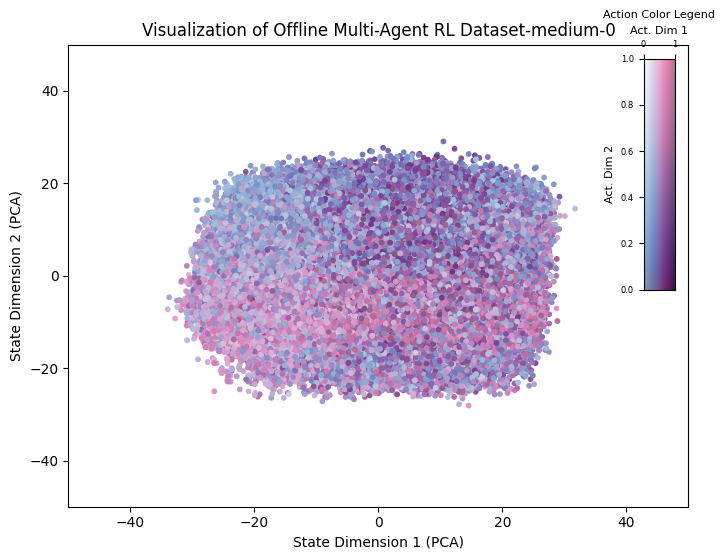

In [41]:
# dataset params
env_id = 'HalfCheetah-v2'  # MPE
data_type = 'medium'  # random medium
dataset_id = 0  # 1 2 3 4
seed = 42

vis_data(env_id, data_type, dataset_id, seed)


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/medium-replay/seed_0_data...
Average_reward: 423.4855521469944


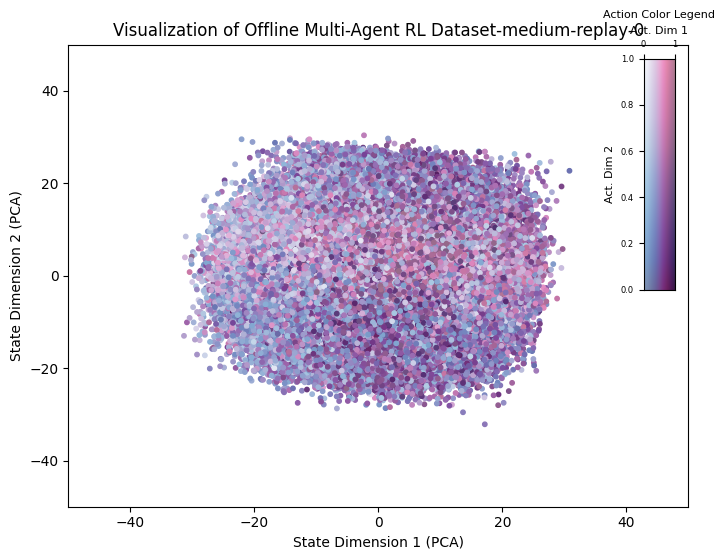

In [43]:
# dataset params
env_id = 'HalfCheetah-v2'  # MPE
data_type = 'medium-replay'  # random medium
dataset_id = 0  # 1 2 3 4
seed = 42

vis_data(env_id, data_type, dataset_id, seed)


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/random/seed_0_data...
Average_reward: -282.8917055694527


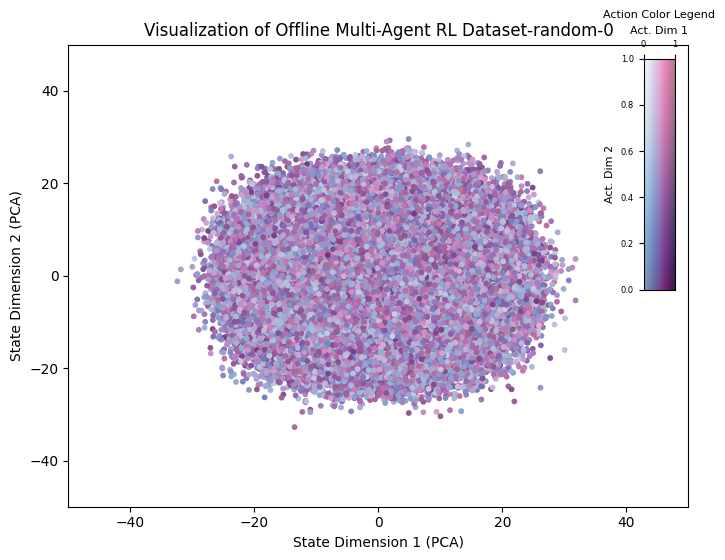

In [44]:
# dataset params
env_id = 'HalfCheetah-v2'  # MPE
data_type = 'random'  # random medium
dataset_id = 0  # 1 2 3 4
seed = 42

vis_data(env_id, data_type, dataset_id, seed)


In [ ]:
# 其实还可以试一下使用了Data Augmentation以后数据集会如何改变，可以更强力的说明DA起到的10%BC作用